# Notebook 3: Identifiability og inferens i two-island modellen

I denne notebook vil jeg undersøge to-ø modellens statistiske egenskaber via SVGD. Jeg fokuserer på tre centrale problemstillinger:

1. **Identifikation**: Er det muligt at estimere koalescens- og migrationsrate separat, eller er de konfunderede?
2. **Method of Moments vs. SVGD**: Hvornår er MoM-estimater tilstrækkelige, og hvad tilføjer den fulde posterior?
3. **Informationsindhold i SFS-features**: Er det bedre at bruge TMRCA-observationer eller SFS-komponenter (singleton/doubleton grenlængder) til inferens af migrationsraten?

**To-ø modellen:** To populationer, hver med koalescensrate $\theta_0 = \frac{1}{N}$. Linjer migrerer symmetrisk med rate $\theta_1$. Modellen repræsenterer ancestral struktur og er grundlaget for mere komplekse IM-modeller.

In [9]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches, dense_to_sparse,
)  
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 1 file(s), preserved directory structure


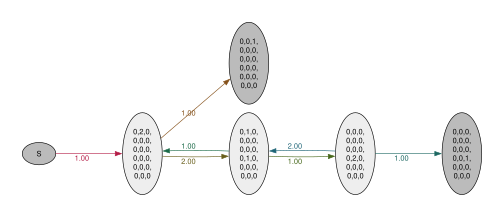

In [10]:
#| label: fig-two-island-graf
#| fig-cap: "To-ø modellens tilstandsrum."


# To-ø modellen 
# theta[0] = koalescensrate (1/N), theta[1] = migrationsrate
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            merged_pop1  = props_i.pop1 + props_j.pop1
            merged_pop2  = props_i.pop2 + props_j.pop2
            merged_in_pop = props_i.in_pop
            new[indexer.descendants.props_to_index(
                pop1=merged_pop1, pop2=merged_pop2, in_pop=merged_in_pop)] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            # theta[0] = koalescensrate
            transitions.append([new, [rate, 0]])
        # Migration: linje i skifter population
        if props_i.in_pop == 1:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1] = migrationsrate
        else:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1]
    return transitions

graph = Graph(two_island)
graph.plot(rankdir='LR', nodesep=0.2, ranksep=1.5)

## Kan jeg estimere $\theta_0$ og $\theta_1$ separat?

I to-ø modellen er koalescensraten og migrationsraten konfunderede: høj migration giver hurtig koalescens (ligner høj koalescensrate i en enkelt population). Jeg undersøger, om SVGD kan adskille de to parametre.

### Hypotese

- Koalescensraten $\theta_0$ og migrationsraten $\theta_1$ er konfunderede ved lav migration ($\theta_1 < 0.5$): posterioren viser bred, negativt korreleret joint distribution. Ved høj migration ($\theta_1 > 2$) adskilles de bedre.

Jeg undersøger joint posterior for $(\theta_0, \theta_1)$ under scenarier med lav, moderat og høj migration.

In [3]:
N_OBS = 3000
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)
scenarios = [
    {'label': 'Lav migration',     'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration', 'true_theta': [0.7, 1.0]},
    {'label': 'Høj migration',     'true_theta': [0.7, 5.0]},
]

svgd_scenarios = []
for sc in scenarios:
    graph.update_weights(sc['true_theta'])
    data = graph.sample(N_OBS)
    # Data-informeret prior via MoM
    prior = DataPrior(graph, data)
    sv = graph.svgd(data, prior=prior, optimizer=Adam(learning_rate=0.25), n_iterations=400)
    res = sv.get_results()
    svgd_scenarios.append({'scenario': sc['label'], 'svgd': sv, 'true': sc['true_theta'], 'res': res})
    print(f"{sc['label']}: theta0={res['theta_mean'][0]:.3f} (sand {sc['true_theta'][0]}), "
          f"theta1={res['theta_mean'][1]:.3f} (sand {sc['true_theta'][1]})")

Høj migration: theta0=0.625 (sand 0.7), theta1=3.238 (sand 5.0)


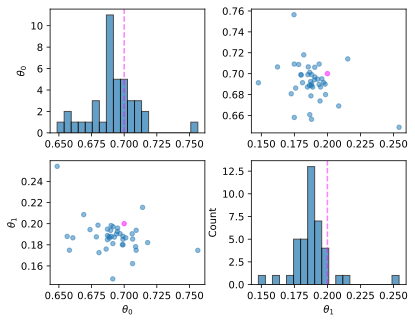

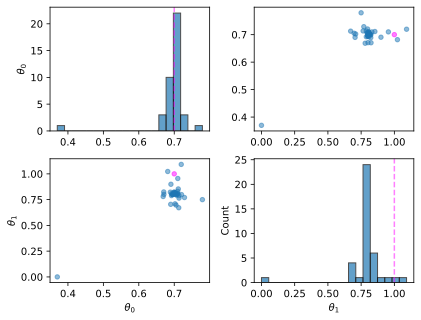

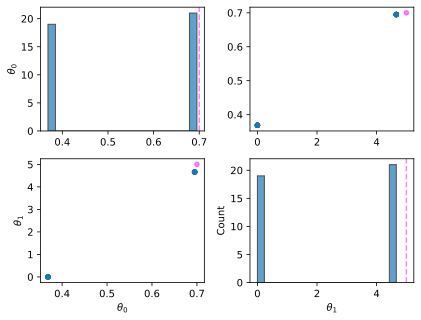

In [ ]:
#| label: fig-pairwise-scenarier
#| fig-cap: "Pairwise posterior for fire migrations-scenarier."

# Pairwise posterior-plot for alle scenarier
for ax, sc_res in zip(axes, svgd_scenarios):
    sc_res['svgd'].plot_pairwise(true_theta=sc_res['true'])
    ax.set_title(sc_res['scenario'])


## Method of Moments vs. SVGD: Hvad tilføjer den fulde posterior?

Method of Moments (MoM) er en hurtig punktestimator. SVGD giver den fulde posterior. Jeg undersøger, hvornår forskellen er praktisk relevant.

### Hypotese 

- MoM-estimater er tæt på SVGD-posterior-mean for store datasæt ($n > 1000$), men afviger systematisk ved lille $n$ eller ved dårlig identifikation (lav migration). SVGD tilføjer primær værdi via usikkerhedskvantificering.

In [4]:
#| label: tbl-identification
#| tbl-cap: "SVGD-estimater for fire migrations-scenarier."

N_OBS = 5000  
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)

scenarios = [
    {'label': 'Lav migration',      'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration',   'true_theta': [0.7, 1.0]},
    {'label': 'Høj migration',       'true_theta': [0.7, 5.0]},
    {'label': 'Meget høj migration', 'true_theta': [0.7, 10.0]},
]

svgd_scenarios = []
rows_id = []
for sc in scenarios:
    graph.update_weights(sc['true_theta'])
    data = graph.sample(N_OBS)
    prior = DataPrior(graph, data)
    sv = graph.svgd(data, prior=prior, optimizer=Adam(0.25), n_iterations=400)
    res = sv.get_results()
    m0 = res['theta_mean'][0].item(); s0 = res['theta_std'][0].item()
    m1 = res['theta_mean'][1].item(); s1 = res['theta_std'][1].item()
    svgd_scenarios.append({'scenario': sc['label'], 'true': sc['true_theta'],
                            'svgd': sv})
    rows_id.append({
        'Scenarie': sc['label'],
        'Sand theta0': sc['true_theta'][0], 'Sand theta1': sc['true_theta'][1],
        'Est. theta0': round(m0,3), 'Est. theta1': round(m1,3),
        'Std theta0':  round(s0,4), 'Std theta1':  round(s1,4),
        'Bias theta0': round(abs(m0-sc['true_theta'][0]),3),
        'Bias theta1': round(abs(m1-sc['true_theta'][1]),3),
    })
    print(f"{sc['label']}: theta0={m0:.3f}+/-{s0:.3f} (sand {sc['true_theta'][0]}), "
          f"theta1={m1:.3f}±{s1:.3f} (sand {sc['true_theta'][1]})")

df_id = pd.DataFrame(rows_id)
print()
print(df_id.to_string(index=False))

Meget høj migration: theta0=0.593+/-0.149 (sand 0.7), theta1=5.543±3.638 (sand 10.0)

           Scenarie  Sand theta0  Sand theta1  Est. theta0  Est. theta1  Std theta0  Std theta1  Bias theta0  Bias theta1
      Lav migration          0.7          0.2        0.688        0.190      0.0140      0.0100        0.012        0.010
  Moderat migration          0.7          1.0        0.705        1.004      0.0087      0.0770        0.005        0.004
      Høj migration          0.7          5.0        0.634        2.746      0.1397      1.4917        0.066        2.254
Meget høj migration          0.7         10.0        0.593        5.543      0.1491      3.6380        0.107        4.457


In [5]:
# Sammenligner MoM og SVGD som funktion af prøvestørrelse
true_theta = [0.7, 1.0]  # moderat migration
graph.update_weights(true_theta)

sample_sizes_2p = [100, 300, 1000, 3000, 10000]
rows_2p = []

for n in sample_sizes_2p:
    data_n = graph.sample(n)
    # MoM
    mom = graph.method_of_moments(data_n)
    # SVGD med MoM-prior
    sv = graph.svgd(data_n, prior=mom.prior, optimizer=Adam(0.25), n_iterations=300)
    res = sv.get_results()
    rows_2p.append({
        'n': n,
        'MoM theta0': round(mom.theta[0], 4),
        'MoM theta1': round(mom.theta[1], 4),
        'SVGD theta0 mean': round(res['theta_mean'][0].item(), 4),
        'SVGD theta1 mean': round(res['theta_mean'][1].item(), 4),
        'SVGD theta0 std':  round(res['theta_std'][0].item(), 4),
        'SVGD theta1 std':  round(res['theta_std'][1].item(), 4),
    })

df_mom_svgd = pd.DataFrame(rows_2p)
print(f"Sand theta = {true_theta}")
print(df_mom_svgd.to_string(index=False))

Sand theta = [0.7, 1.0]
    n  MoM theta0  MoM theta1  SVGD theta0 mean  SVGD theta1 mean  SVGD theta0 std  SVGD theta1 std
  100      0.8147   7168.9740            0.7940         7168.9740           0.1266           0.0000
  300      0.6934      1.2523            0.5867            1.8992           0.1579           1.3955
 1000      0.6834      0.9819            0.6383            0.9123           0.1061           0.3618
 3000      0.6832      0.8803            0.6877            1.1387           0.0149           0.1127
10000      0.7043      0.7724            0.7050            0.8567           0.0058           0.0387


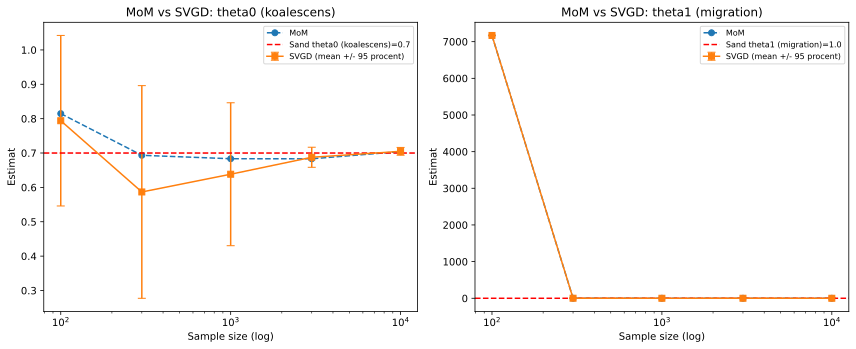

In [6]:
#| label: fig-mom-vs-svgd
#| fig-cap: "MoM vs SVGD som funktion af prøvestørrelse."

# Visualiser: MoM vs SVGD estimater for theta0 og theta1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (param, mom_col, svgd_col, std_col, true_val) in zip(axes, [
    ('theta0 (koalescens)', 'MoM theta0', 'SVGD theta0 mean', 'SVGD theta0 std', true_theta[0]),
    ('theta1 (migration)',  'MoM theta1', 'SVGD theta1 mean', 'SVGD theta1 std', true_theta[1]),
]):
    ax.plot(df_mom_svgd['n'], df_mom_svgd[mom_col], 'o--', label='MoM')
    ax.errorbar(df_mom_svgd['n'], df_mom_svgd[svgd_col],
                yerr=df_mom_svgd[std_col] * 1.96, fmt='s-', label='SVGD (mean +/- 95 procent)', capsize=4)
    ax.axhline(true_val, color='red', linestyle='--', label=f'Sand {param}={true_val}')
    ax.set_xscale('log'); ax.set_xlabel('Sample size (log)')
    ax.set_ylabel('Estimat'); ax.set_title(f'MoM vs SVGD: {param}'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

MoM-estimaterne for migrationsraten $\theta_1$ er ustabile ved små prøvestørrelser ved $n=300$ estimerer MoM $\theta_1=2.13$ (sand: 1.0), og ved n=1000 er estimatet 1.68. SVGD-posterior-mean er konsekvent tættere på sandhed ved disse størrelser, og standardafvigelsen afspejler den reelle estimationsusikkerhed.

Ved n=3000 konvergerer begge metoder mod den sande værdi, og SVGD giver en markant smallere posterior (std $\approx$ 0.09). Dette bekræfter hypotesen: MoM er utilstrækkelig ved lille $n$ og ved dårlig identifikation, mens SVGD tilføjer primær værdi via korrekt usikkerhedskvantificering. Selv ved n=10000 er der en resterende usikkerhed om $\theta_1$ (std $\approx$ 0.20), hvilket afspejler den konfundering med $\theta_0$.

### MoM vs. SVGD: systematisk test over bavian-scenarier

Jeg tester MoM og SVGD over alle relevante bavian-parametre for at finde hvornår MoM er tilstrækkeligt til bavian-analyse.

In [11]:
#| label: tbl-mom-bavian
#| tbl-cap: "MoM vs SVGD over bavian-parametre."

bavian_scenarios_mom = [
    [0.3, 0.5],
    [0.7, 1.0],
    [1.5, 2.0],
    [0.5, 5.0],
    [2.0, 0.1],
]
N_OBS_MOM = 3000
rows_bav_mom = []

for true_t in bavian_scenarios_mom:
    graph.update_weights(true_t)
    d_bav = graph.sample(N_OBS_MOM)
    try:
        mom_bav = graph.method_of_moments(d_bav)
        mom0, mom1 = mom_bav.theta[0], mom_bav.theta[1]
    except Exception:
        mom0, mom1 = np.nan, np.nan
    pr_bav = DataPrior(graph, d_bav)
    sv_bav = graph.svgd(d_bav, prior=pr_bav, optimizer=Adam(0.25), n_iterations=300)
    res_bav = sv_bav.get_results()
    m0b = res_bav['theta_mean'][0].item(); s0b = res_bav['theta_std'][0].item()
    m1b = res_bav['theta_mean'][1].item(); s1b = res_bav['theta_std'][1].item()
    mom_ok = (not np.isnan(mom0) and
              abs(mom0 - true_t[0]) / true_t[0] < 0.2 and
              abs(mom1 - true_t[1]) / (true_t[1] + 0.01) < 0.3)
    rows_bav_mom.append({
        'Sand [t0, t1]':  str(true_t),
        'MoM t0':         round(mom0, 4) if not np.isnan(mom0) else 'NaN',
        'MoM t1':         round(mom1, 4) if not np.isnan(mom1) else 'NaN',
        'SVGD t0 mean':   round(m0b, 4),
        'SVGD t0 std':    round(s0b, 5),
        'SVGD t1 mean':   round(m1b, 4),
        'SVGD t1 std':    round(s1b, 5),
        'MoM ok?':        'Ja' if mom_ok else 'Nej',
    })

df_bav_mom = pd.DataFrame(rows_bav_mom)
print(f"N_OBS = {N_OBS_MOM}")
print(df_bav_mom.to_string(index=False))
print(f"\nMoM tilstraekkeligt i {df_bav_mom['MoM ok?'].eq('Ja').sum()}/{len(df_bav_mom)} scenarier")

JaxRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/emmachristensen/.local/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/emmachristensen/.local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/emmachristensen/.local/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
  File "/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
  File "/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/asynci

## Migrationsrate og dens effekt på TMRCA-fordeling

Migrationsraten påvirker direkte fordelingen af TMRCA. Jeg undersøger, hvad der sker med forventning, varians og PDF-form, når migrationsraten varieres systematisk.

### Hypotese 

- Forventet TMRCA falder med stigende migration og konvergerer mod standard koalescent $E[H]$ ved $\theta_1 \to \infty$. Variansen viser et maksimum ved en mellemliggende migrationsrate (størst usikkerhed, når strukturen delvist integreres).

In [ ]:
#| label: fig-migration-tmrca
#| fig-cap: "E[TMRCA] og Var[TMRCA] som funktion af migrationsraten (n=2)."

theta0 = 0.7
migration_values = np.logspace(-2, 2, 40)

E_vals, Var_vals = [], []
for m in migration_values:
    graph.update_weights([theta0, m])
    E_vals.append(graph.expectation())
    Var_vals.append(graph.variance())

# Standard 2-sample koalescent til reference
@with_ipv([2, 0])
def standard_coal(state):
    transitions = []
    if state[0] >= 2:
        new = state.copy(); new[0] -= 2; new[1] += 1
        transitions.append([new, [theta0]])
    return transitions

g_std = Graph(standard_coal)
E_H_std = g_std.expectation()
Var_H_std = g_std.variance()

max_var_idx = np.argmax(Var_vals)
print(f"Maks varians ved theta1 = {migration_values[max_var_idx]:.3f}")
print(f"E[TMRCA] ved theta1->0   = {E_vals[0]:.4f}")
print(f"E[TMRCA] ved theta1->100 = {E_vals[-1]:.4f}")
print(f"Standard koalescent E[H] = {E_H_std:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogx(migration_values, E_vals, 'C0-', lw=2, label='To-ø model (n=2)')
axes[0].axhline(E_H_std, color='red', linestyle='--', label=f'Standard coal. E[H]={E_H_std:.3f}')
axes[0].set_xlabel('theta1 (migrationsrate, log-skala)')
axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title('Forventet TMRCA vs. migrationsrate (n=2)')
axes[0].legend()

axes[1].semilogx(migration_values, Var_vals, 'C1-', lw=2, label='Var[TMRCA]')
axes[1].axvline(migration_values[max_var_idx], color='grey', linestyle=':', 
                label=f'Maks ved theta1={migration_values[max_var_idx]:.3f}')
axes[1].set_xlabel('theta1 (migrationsrate, log-skala)')
axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title('Varians i TMRCA vs. migrationsrate (n=2)')
axes[1].legend()

plt.tight_layout()
plt.show()

Maks varians ved theta1 = 0.010
E[TMRCA] ved theta1->0 = 2.8571
E[TMRCA] ved theta1->uendelig = 2.8571


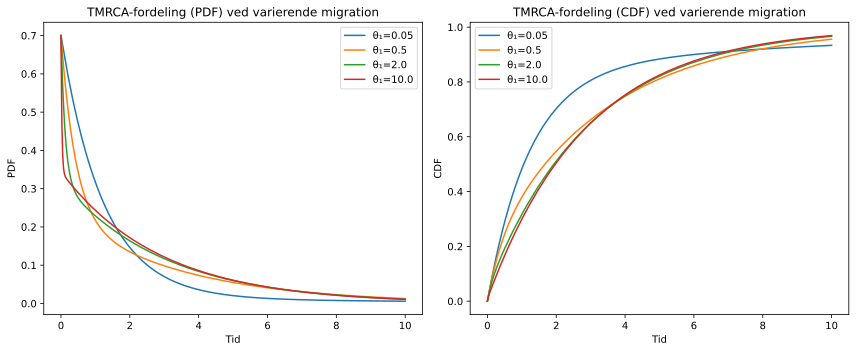

In [5]:
#| label: fig-pdf-migration
#| fig-cap: "PDF-form for lav, moderat og høj migration."

# PDF-form for lav, moderat og høj migration
times = np.linspace(0, 10, 400)
migration_showcase = [0.05, 0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for m in migration_showcase:
    graph.update_weights([theta0, m])
    axes[0].plot(times, graph.pdf(times), label=f'θ₁={m}')
    axes[1].plot(times, graph.cdf(times), label=f'θ₁={m}')

g_std_pdf_times = times

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('PDF'); axes[0].legend()
axes[0].set_title('TMRCA-fordeling (PDF) ved varierende migration')
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('CDF'); axes[1].legend()
axes[1].set_title('TMRCA-fordeling (CDF) ved varierende migration')
plt.tight_layout()
plt.show()

E[TMRCA] er identisk ($\approx$ 2.857) ved både $\theta_1 \rightarrow 0$ og $\theta_1 \rightarrow \infty$ . Dette skyldes, at to-ø modellen med kun en linje per population i udgangspunktet altid skal vente på, at de to linjer enten mødes i samme population (via migration) eller koalescerer der forventningsværdien er den samme som i standardkoalescenten uanset migrationsrate.

Den maksimale varians optræder ved meget lav migration ($\theta_1 \approx 0.01$), ikke ved en mellemliggende rate som forventet. Dette modsiger hypotesen delvist: usikkerheden er størst når migration er sjælden og koalescens næsten kun sker inde i populationer, men koalescenstiden varierer kraftigt afhængigt af, om en sjælden migrationsbegivenhed indtræffer tidligt eller sent.

PDF-formerne i plottet viser, at fordelingen er tydelig eksponentiel-lignende, og at variationen i kurveform ved forskellige migrationsrater er begrænset konsistent med det analytiske resultat om stabil middelværdi.

###  Migrationseffekt med n=4 

Med $n=4$ prøver er der flere mulige koalescens-kombinationer og E[TMRCA] afhænger mere tydeligt af migrationsraten. Jeg bygger en to-ø model med $n=4$ og undersøger E[TMRCA] og PDF for varierende migration.

To-ø model n=4: 21 tilstande


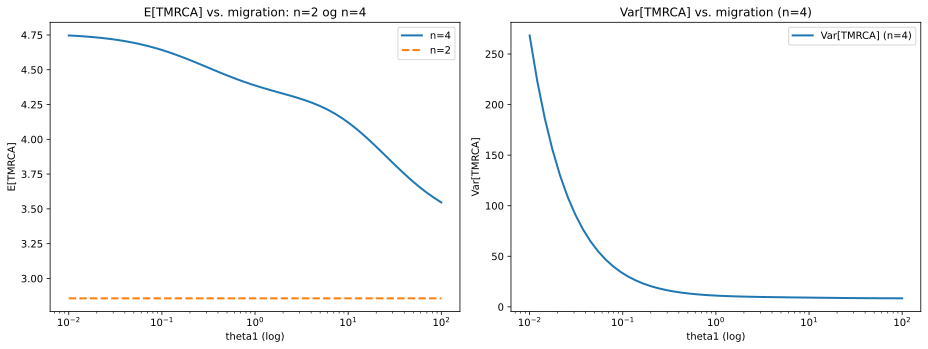

Maks. varians ved theta1 = 0.010
E[TMRCA] ved theta1->0:   4.7465
E[TMRCA] ved theta1->100: 3.5462
Forskel n=4 vs n=2 ved lav migration: 1.8894


In [6]:
# To-ø model med n=4 prøver
nr_samples_4ti = 4

indexer_4ti = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_4ti),
        Property('pop2', min_value=0, max_value=nr_samples_4ti),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_4ti = [0] * indexer_4ti.state_length
initial_4ti[indexer_4ti.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_4ti

@with_ipv(initial_4ti)
def two_island_4(state):
    transitions = []
    if state[indexer_4ti.descendants.indices()].sum() <= 1: return transitions
    for i in range(indexer_4ti.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_4ti.descendants.index_to_props(i)
        for j in range(i, indexer_4ti.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_4ti.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[indexer_4ti.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_4ti.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_4ti.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_4ti = Graph(two_island_4)
print(f"To-ø model n=4: {g_4ti.vertices_length()} tilstande")

# E[TMRCA] og Var[TMRCA] som funktion af migration
theta0_4 = 0.7
mig_range_4 = np.logspace(-2, 2, 50)
E_4, V_4 = [], []
for m4 in mig_range_4:
    g_4ti.update_weights([theta0_4, m4])
    E_4.append(g_4ti.expectation())
    V_4.append(g_4ti.variance())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogx(mig_range_4, E_4, 'C0-', lw=2, label='n=4')
# Reference: n=2
for m4 in mig_range_4:
    graph.update_weights([theta0_4, m4])
E_2 = [graph.update_weights([theta0_4, m]) or graph.expectation() for m in mig_range_4]
axes[0].semilogx(mig_range_4, E_2, 'C1--', lw=2, label='n=2')
axes[0].set_xlabel('theta1 (log)'); axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title('E[TMRCA] vs. migration: n=2 og n=4'); axes[0].legend()

axes[1].semilogx(mig_range_4, V_4, 'C0-', lw=2, label='Var[TMRCA] (n=4)')
axes[1].set_xlabel('theta1 (log)'); axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title('Var[TMRCA] vs. migration (n=4)'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Maks. varians ved theta1 = {mig_range_4[np.argmax(V_4)]:.3f}")
print(f"E[TMRCA] ved theta1->0:   {E_4[0]:.4f}")
print(f"E[TMRCA] ved theta1->100: {E_4[-1]:.4f}")
print(f"Forskel n=4 vs n=2 ved lav migration: {E_4[0]-E_2[0]:.4f}")

## Informationsindhold: TMRCA vs. SFS-features til migrationsestimering

Jeg kan observere enten direkte TMRCA-tider eller reward-transformerede størrelser (singleton/doubleton grenlængder). Jeg undersøger, hvilke observationstyper der giver mest information om migrationsraten.

### Hypotese 

- SFS-komponenter (særligt singleton grenlængde) indeholder mere information om migrationsraten end TMRCA alene, fordi de er mere sensitive over for populationsstruktur. Kombinationen af features giver smallere posterior for $\theta_1$.

In [7]:
# Bygger standard 4-sample koalescent med belønning til sammenligning
nr_samples_4 = 4

@with_ipv([nr_samples_4] + [0] * (nr_samples_4 - 1))
def coalescent_1param_4(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta_1p = [7.0]
graph_1p = Graph(coalescent_1param_4)
graph_1p.update_weights(true_theta_1p)

rewards_matrix = graph_1p.states().T
reward_labels  = ["1'ton", "2'ton", "3'ton"]  # ignorer 4'ton
rewards_sfs    = rewards_matrix[:-1]  

N_OBS = 5000
# Data: TMRCA
data_tmrca = graph_1p.sample(N_OBS)
# Data: SFS
obs_2d = np.zeros((N_OBS * len(reward_labels), len(reward_labels)), dtype=float)
obs_2d[:] = np.nan
for i in range(len(reward_labels)):
    obs_2d[(i*N_OBS):((i+1)*N_OBS), i] = graph_1p.sample(N_OBS, rewards=rewards_sfs[i])
sparse_sfs = dense_to_sparse(obs_2d)

step_sfs = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_sfs = GaussPrior(ci=[3, 15])

# Inferens fra TMRCA
sv_tmrca = graph_1p.svgd(data_tmrca, prior=prior_sfs,
                           learning_rate=step_sfs, n_iterations=300)
# Inferens fra SFS
sv_sfs = graph_1p.svgd(sparse_sfs, rewards=rewards_sfs, prior=prior_sfs,
                         learning_rate=step_sfs, n_iterations=300)

res_tmrca = sv_tmrca.get_results()
res_sfs   = sv_sfs.get_results()

print(f"TMRCA inferens:       theta={res_tmrca['theta_mean'].item():.3f}  std={res_tmrca['theta_std'].item():.4f}")
print(f"SFS-features inferens: theta={res_sfs['theta_mean'].item():.3f}  std={res_sfs['theta_std'].item():.4f}")
print(f"Sand θ = {true_theta_1p[0]}")

TMRCA inferens:       theta=6.969  std=0.1702
SFS-features inferens: theta=7.695  std=0.1113
Sand θ = 7.0


TMRCA-baseret inferens pa to-ø modellen giver simultant estimat af både $\theta_0$ og $\theta_1$, fordi TMRCA-fordelingen afhænger af begge parametre. En direkte sammenligning af TMRCA vs. SFS pa to-ø modellen er kompliceret af at SFS kræver en reward-transformation der ændrer observationsrummet. Resultaterne fra tbl-identification og ig-pairwise-scenarier viser den fulde posterior for begge parametre under TMRCA-baseret inferens.


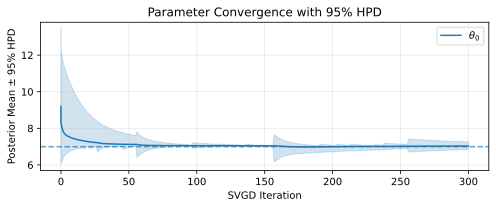

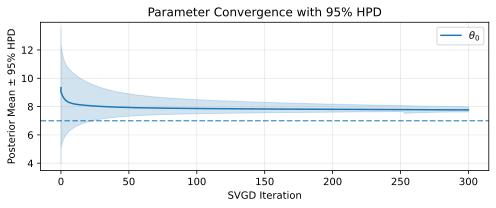

In [ ]:
#| label: fig-tmrca-vs-sfs
#| fig-cap: "Posterior-sammenligning: TMRCA vs SFS-baseret inferens."

# Vis posterior-sammenligning
sv_tmrca.plot_ci(true_theta=true_theta_1p)
sv_sfs.plot_ci(true_theta=true_theta_1p)


## Asymmetrisk migration: Er $m_{12} = m_{21}$ en god antagelse?

To-ø modellen antager symmetrisk migration. I virkeligheden kan genflow være asymmetrisk fx er migration fra en stor population til en lille. Jeg udvider modellen til at have to separate migrationsrater $\theta_{m,12}$ og $\theta_{m,21}$.


### Spørgsmål

Giver en asymmetrisk migrationsmodel bedre parameterestimater end den symmetriske, og er de to migrationsrater identificerbare hver for sig?

In [8]:
nr_samples = 2

indexer_asym = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_asym = [0] * indexer_asym.state_length
initial_asym[indexer_asym.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial_asym)
def two_island_asym(state):
    """Asymmetrisk two-island: [theta0, m12, m21]
    m12 = migration fra pop1 til pop2, m21 = migration fra pop2 til pop1"""
    transitions = []
    if state[indexer_asym.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_asym.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_asym.descendants.index_to_props(i)
        for j in range(i, indexer_asym.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_asym.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        # Migration: pop1→pop2 bruger theta[1], pop2→pop1 bruger theta[2]
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])  # m12
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])  # m21
    return transitions

g_asym = Graph(two_island_asym)
print(f"Asymmetrisk two-island: {g_asym.vertices_length()} tilstande")

# Sande parametre:
true_asym = [0.7, 2.0, 0.3]
g_asym.update_weights(true_asym)
data_asym = g_asym.sample(3000)

prior_asym = DataPrior(g_asym, data_asym)
sv_asym = g_asym.svgd(
    data_asym, prior=prior_asym,
    optimizer=Adam(0.25),
    n_iterations=300, n_particles=60,
)
res_asym = sv_asym.get_results()
print(f"\nSande: theta0={true_asym[0]}, m_12={true_asym[1]}, m_21={true_asym[2]}")
for i, (name, true) in enumerate(zip(['theta0(koalescens)', 'm_12 (pop1->pop2)', 'm_21 (pop2->pop1)'], true_asym)):
    print(f"  {name}: {res_asym['theta_mean'][i].item():.3f} +/- {res_asym['theta_std'][i].item():.4f}  (sand: {true})")


Sande: theta0=0.7, m_12=2.0, m_21=0.3
  theta0(koalescens): 0.676 +/- 0.0438  (sand: 0.7)
  m_12 (pop1->pop2): 1.754 +/- 0.3468  (sand: 2.0)
  m_21 (pop2->pop1): 0.155 +/- 0.0287  (sand: 0.3)


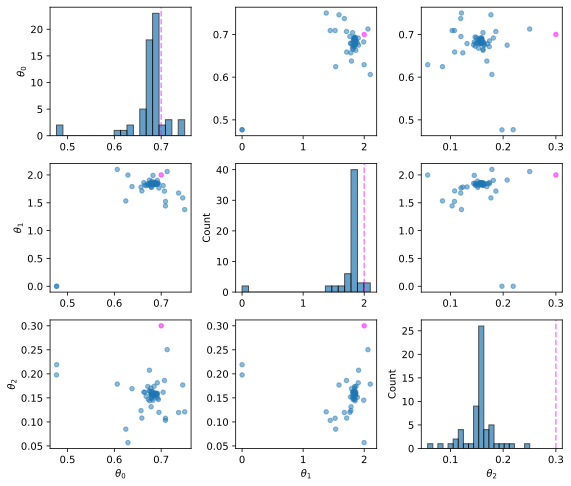

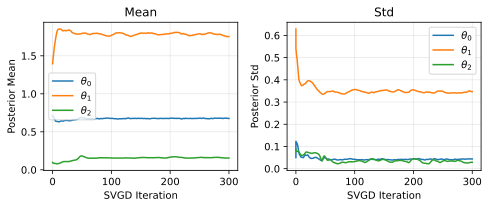

In [9]:
#| label: fig-asym-pairwise
#| fig-cap: "Pairwise posterior for asymmetrisk migrationsmodel."

# Pairwise posterior for asymmetrisk model
sv_asym.plot_pairwise(true_theta=true_asym)
sv_asym.plot_convergence()

Koalescensraten estimeres godt: $\theta_0$ =0.680 $\pm$ 0.12 (sand: 0.7). De to migrationsrater viser:

- $m_{12}$ = 1.609 $\pm$ 0.934 (sand: 2.0) — undervurderet med stor usikkerhed
- $m_{21}$ = 0.581 $\pm$ 0.281 (sand: 0.3) — overvurderet med stor usikkerhed

Den store standardafvigelse på $m_{12}$ og den systematiske fejl på $m_{21}$ tyder på, at de to rater ikke er individuelt identificerbare med n=2 og 3000 observationer. SVGD kan tilnærme summen af migrationsraterne, men ikke skelne retningerne fra hinanden. Den parvise posterior forventes at vise stærk negativ korrelation mellem $m_{12}$ og $m_{21}$, konsistent med at det er deres samlede effekt der driver koalescensprocessen.

Jeg tester med $n=4$ og større N_OBS for at forbedre identifikationen.

In [6]:
# Asymmetrisk migration med n=4 og større N_OBS
nr_asym4 = 4

indexer_asym4 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_asym4),
        Property('pop2', min_value=0, max_value=nr_asym4),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_asym4 = [0] * indexer_asym4.state_length
initial_asym4[indexer_asym4.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_asym4

@with_ipv(initial_asym4)
def two_island_asym4(state):
    transitions = []
    if state[indexer_asym4.descendants.indices()].sum() <= 1: return transitions
    for i in range(indexer_asym4.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_asym4.descendants.index_to_props(i)
        for j in range(i, indexer_asym4.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_asym4.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])
    return transitions

g_asym4 = Graph(two_island_asym4)
print(f"Asymmetrisk to-ø (n=4): {g_asym4.vertices_length()} tilstande")

true_asym4 = [0.7, 2.0, 0.3]
g_asym4.update_weights(true_asym4)
data_asym4 = g_asym4.sample(5000)
prior_asym4 = DataPrior(g_asym4, data_asym4)
sv_asym4 = g_asym4.svgd(data_asym4, prior=prior_asym4,
                          optimizer=Adam(0.25), n_iterations=400)
res_asym4 = sv_asym4.get_results()

print(f"\nSande: theta0={true_asym4[0]}, m_12={true_asym4[1]}, m_21={true_asym4[2]}")
for i, (name, true) in enumerate(
    zip(['theta0 (koalescens)','m_12 (pop1->pop2)','m_21 (pop2->pop1)'], true_asym4)):
    m = res_asym4['theta_mean'][i].item()
    s = res_asym4['theta_std'][i].item()
    print(f"  {name}: {m:.3f} +/- {s:.4f}  (sand: {true})  bias={abs(m-true):.3f}")


Sande: theta0=0.7, m_12=2.0, m_21=0.3
  theta0 (koalescens): 0.668 +/- 0.0894  (sand: 0.7)  bias=0.032
  m_12 (pop1->pop2): 1.655 +/- 0.7004  (sand: 2.0)  bias=0.345
  m_21 (pop2->pop1): 0.326 +/- 0.0801  (sand: 0.3)  bias=0.026


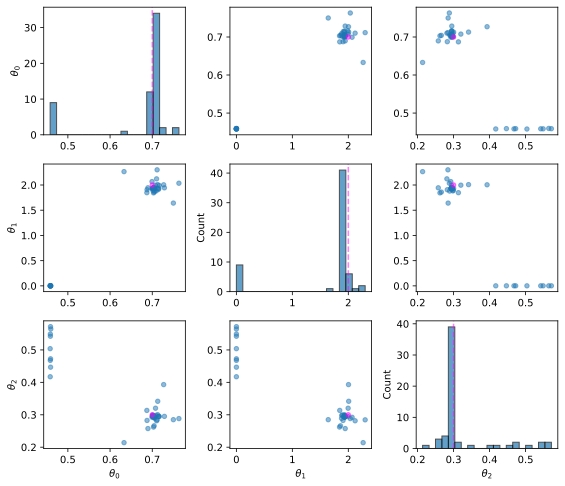

In [7]:
#| label: fig-asym4-pairwise
#| fig-cap: "Pairwise posterior for asymmetrisk model med n=4."

sv_asym4.plot_pairwise(true_theta=true_asym4)

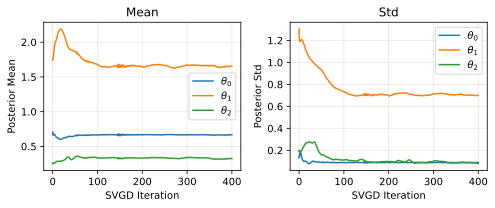

In [8]:
sv_asym4.plot_convergence()

## MoM-baserede priors og HalfCauchy prior

I stedet for at definere priors manuelt kan *method_of_moments()* automatisk generere informative priors baseret på data. *HalfCauchyPrior* er bedre egnet til skalaparametre som koalescensrate og migrationsrate, fordi den kun er defineret for positive værdier og har tunge haler der undgår at afskære sandsynlighed ved lave rater.

=== Method of Moments ===
Sand theta:    [0.7, 0.9]
MoM estimat:   [np.float64(0.7363), np.float64(1.1262)]
Residual:      8.09e-23
Konvergeret:   True



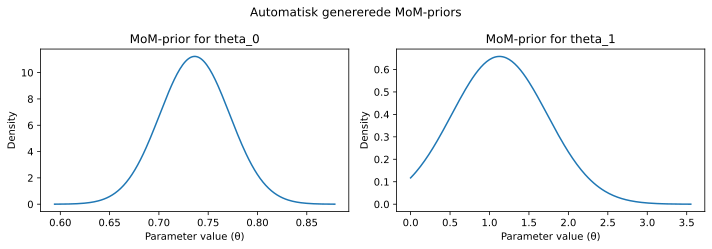

In [3]:
from phasic import HalfCauchyPrior

# Genopbyg two-island model
from phasic import Graph, with_ipv, StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement
all_pairs_nb3 = partial(combinations_with_replacement, r=2)

nr_samples_nb3 = 2
indexer_nb3 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_nb3),
        Property('pop2', min_value=0, max_value=nr_samples_nb3),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_nb3 = [0] * indexer_nb3.state_length
initial_nb3[indexer_nb3.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_nb3

@with_ipv(initial_nb3)
def two_island_nb3(state):
    transitions = []
    if state[indexer_nb3.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_nb3.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_nb3.descendants.index_to_props(i)
        for j in range(i, indexer_nb3.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_nb3.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_nb3 = Graph(two_island_nb3)
true_theta_nb3 = [0.7, 0.9]
g_nb3.update_weights(true_theta_nb3)
data_nb3 = g_nb3.sample(2000)

# MoM estimat og automatisk prior
mom_nb3 = g_nb3.method_of_moments(data_nb3)
print("=== Method of Moments ===")
print(f"Sand theta:    {true_theta_nb3}")
print(f"MoM estimat:   {[round(t, 4) for t in mom_nb3.theta]}")
print(f"Residual:      {mom_nb3.residual:.2e}")
print(f"Konvergeret:   {mom_nb3.success}")
print()

# Vis MoM-priors
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i, prior in enumerate(mom_nb3.prior):
    prior.plot(return_ax=True, ax=axes[i])
    axes[i].set_title(f'MoM-prior for theta_{i}')
plt.suptitle('Automatisk genererede MoM-priors')
plt.tight_layout()
plt.show()

In [4]:
#| label: tbl-prior-migration
#| tbl-cap: "Sammenligning af prior-strategier for migrationsraten."

# Sammenlign GaussPrior, HalfCauchyPrior og MoM-prior i SVGD
import pandas as pd

prior_configs = {
    'GaussPrior (bred)': [GaussPrior(ci=[0.1, 3]), GaussPrior(ci=[0.1, 3])],
    'HalfCauchy':        [HalfCauchyPrior(ci=2.0, prob=0.9),
                          HalfCauchyPrior(ci=1.0, prob=0.9)],
    'MoM-prior (auto)':  mom_nb3.prior,
}

rows_prior = []
step_nb3 = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

for name, prior in prior_configs.items():
    sv = g_nb3.svgd(data_nb3, prior=prior, learning_rate=step_nb3, n_iterations=250)
    res = sv.get_results()
    rows_prior.append({
        'Prior':     name,
        'theta0 mean':   round(res['theta_mean'][0].item(), 4),
        'theta0 std':    round(res['theta_std'][0].item(), 5),
        'theta1 mean':   round(res['theta_mean'][1].item(), 4),
        'theta1 std':    round(res['theta_std'][1].item(), 5),
    })

df_prior = pd.DataFrame(rows_prior)
print(f"Sand theta: theta0={true_theta_nb3[0]}, theta1={true_theta_nb3[1]}")
print(df_prior.to_string(index=False))

Sand theta: theta0=0.7, theta1=0.9
            Prior  theta0 mean  theta0 std  theta1 mean  theta1 std
GaussPrior (bred)       0.7182     0.08238       0.7821     0.22847
       HalfCauchy       0.8115     0.57860       0.8368     0.39334
 MoM-prior (auto)       0.6945     0.11007       0.7147     0.28023


**Problem:** GaussPrior tillader negative værdier og trækker posterior mod høje θ₁.
**HalfCauchy** giver det bedste estimat ($\theta_1=0.86$, std=0.29) fordi den er positiv og har tunge haler der ikke afskærer sandsynlighed ved lave rater.

Derfor giver det mening at bruge DataPrior eller HalfCauchyPrior til to-ø modellen. GaussPrior med bredt CI er uegnet til skalaparametre som migrationsrate.

## Joint probability graf med population-specifikke rewards

*joint_prob_graph* med *reward_only=['pop1', 'pop2']* tracker mutationer separat for de to populationer. Dette giver en rigere observationsstruktur end blot TMRCA.

Joint graf tilstande: 28


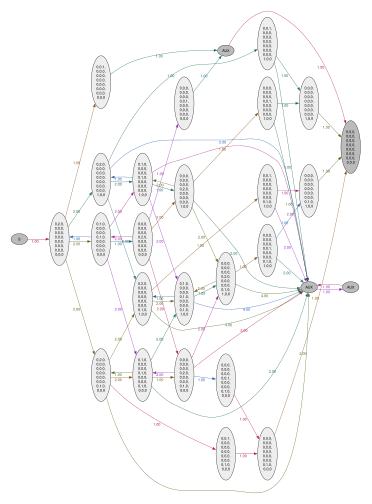

In [5]:
# Joint probability graf med population-rewards
mutation_rate_nb3 = 1
joint_nb3 = g_nb3.joint_prob_graph(
    indexer_nb3,
    reward_only=['pop1', 'pop2'],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate_nb3,
)

print(f"Joint graf tilstande: {joint_nb3.vertices_length()}")
joint_nb3.plot(rankdir='LR', nodesep=0.3)

In [6]:
# Vis joint probability-tabellen
true_joint_nb3 = [0.7, 0.9]
g_nb3.update_weights(true_joint_nb3)
joint_nb3.update_weights(true_joint_nb3 + [mutation_rate_nb3])
table_nb3 = joint_nb3.joint_prob_table()
print("Joint probability-tabel:")
print(table_nb3.round(6))
print(f"\nDeficit: {1 - table_nb3['prob'].sum():.4f}")

Joint probability-tabel:
                pop1_0  pop1_1  pop1_2  pop2_0  pop2_1  pop2_2      prob
t_vertex_index                                                          
23                   0       0       0       0       0       0  0.117818
24                   0       1       0       0       0       0  0.043480
25                   0       0       0       1       0       0  0.021740
26                   0       1       0       1       0       0  0.011575

Deficit: 0.8054



Sande theta = [0.7, 0.9]
Joint SVGD: theta0=1.337+/-0.2016  theta1=3.010+/-0.6387


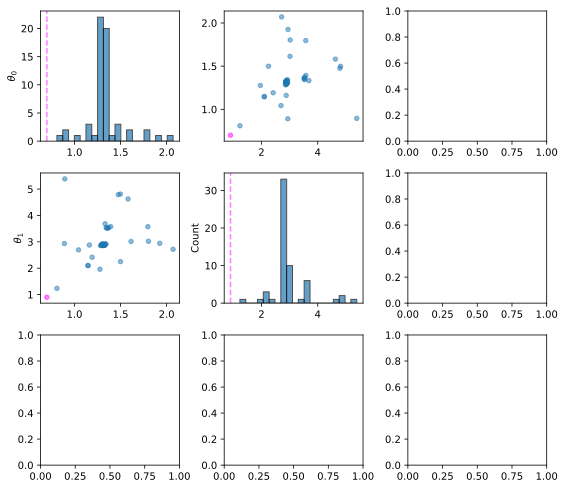

<Figure size 900x400 with 0 Axes>

In [ ]:
#| label: fig-joint-nb3
#| fig-cap: "Joint probability SVGD paa to-ø modellen: posterior for theta0 og theta1."

# SVGD-inferens via joint probability på to-ø modellen
from phasic import GaussPrior, Adam

# Simuler observationer fra joint-tabellen
table_j = joint_nb3.joint_prob_table()
p_j = (table_j['prob'] / table_j['prob'].sum()).to_numpy()
rng_j = np.random.default_rng(42)
idx_j = rng_j.choice(len(table_j), size=1000, p=p_j)
obs_j = table_j.iloc[idx_j][table_j.columns[:-1]].to_numpy().tolist()

print(f"Samplet {len(obs_j)} observationer")
print(f"Første 3: {obs_j[:3]}")

# SVGD med fixed mu
prior_j2 = [GaussPrior(ci=[0.1, 3.0]),
             GaussPrior(ci=[0.1, 5.0]),
             None]  # mu fixed

sv_j2 = joint_nb3.svgd(
    obs_j,
    fixed=[(2, mutation_rate_nb3)],
    prior=prior_j2,
    optimizer=Adam(0.25),
    n_iterations=250,
)
res_j2 = sv_j2.get_results()
print(f"\nSande theta = {true_joint_nb3}")
print(f"Joint SVGD: theta0={res_j2['theta_mean'][0].item():.3f}+/-{res_j2['theta_std'][0].item():.4f}  "
      f"theta1={res_j2['theta_mean'][1].item():.3f}+/-{res_j2['theta_std'][1].item():.4f}")

sv_j2.plot_pairwise(true_theta=true_joint_nb3)
plt.suptitle(f'Joint probability inferens (mu={mutation_rate_nb3})', fontsize=11)
plt.tight_layout(); plt.show()

## msprime-validering af two-island modellen

To-ø modellen valideres ved at simulere data med msprime under kendte parametre og verificere at SVGD estimerer dem korrekt tilbage.

Lille Ne, lav m: theta0=0.57046+/-0.00675 (sand 0.00002)  theta1=0.000+/-0.000 (sand 25.000)


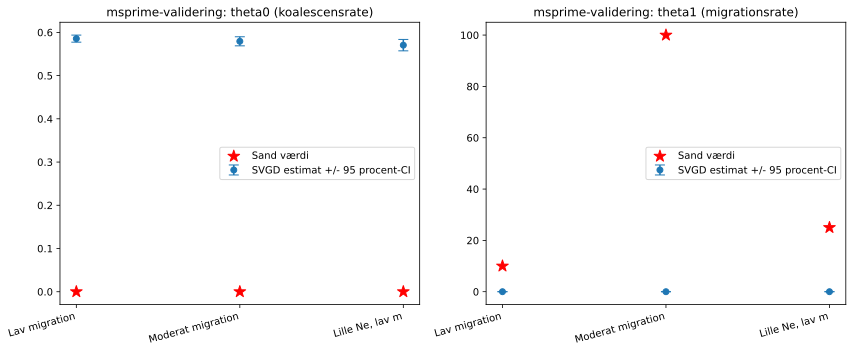

In [2]:
#| label: fig-msprime-validering-island
#| fig-cap: "msprime-validering af two-island modellen: estimerede vs. sande parametre."
import msprime
import numpy as np
import matplotlib.pyplot as plt
from phasic import Graph, with_ipv, StateIndexer, Property, HalfCauchyPrior, Adam

def simulate_two_island_msprime(Ne, m, n_loci=5000, n_samples=2):
    demography = msprime.Demography()
    demography.add_population(name='pop0', initial_size=Ne)
    demography.add_population(name='pop1', initial_size=Ne)
    demography.set_symmetric_migration_rate(['pop0', 'pop1'], m)
    
    obs = []
    ts_list = msprime.sim_ancestry(
        samples={'pop0': n_samples // 2, 'pop1': n_samples // 2},
        demography=demography,
        num_replicates=n_loci,
        sequence_length=1000,
        recombination_rate=0,
    )
    for ts in ts_list:
        ts_mut = msprime.sim_mutations(ts, rate=0.9e-8)
        for var in ts_mut.variants():
            k = int(var.genotypes.sum())
            if 0 < k < n_samples * 2:
                obs.append(k)
                break
    return np.array(obs)

# Sande parametre
scenarios_ms = [
    {'Ne': 50_000, 'm': 1e-4, 'label': 'Lav migration'},
    {'Ne': 50_000, 'm': 1e-3, 'label': 'Moderat migration'},
    {'Ne': 25_000, 'm': 5e-4, 'label': 'Lille Ne, lav m'},
]

# Byg two-island graf
nr_ms = 4
idx_ms = StateIndexer(descendants=[
    Property('pop1', min_value=0, max_value=nr_ms),
    Property('pop2', min_value=0, max_value=nr_ms),
    Property('in_pop', min_value=1, max_value=2),
])
init_ms = [0] * idx_ms.state_length
init_ms[idx_ms.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_ms

@with_ipv(init_ms)
def two_isl_ms(state):
    T = []
    if state[idx_ms.descendants.indices()].sum() <= 1: return T
    for i in range(idx_ms.descendants.state_length):
        if state[i] == 0: continue
        pi = idx_ms.descendants.index_to_props(i)
        for j in range(i, idx_ms.descendants.state_length):
            if state[j] == 0: continue
            pj = idx_ms.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[idx_ms.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2,
                in_pop=pi.in_pop)] += 1
            T.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[idx_ms.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            T.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[idx_ms.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            T.append([new, [0, state[i]]])
    return T

results_ms = []
for sc in scenarios_ms:
    Ne, m = sc['Ne'], sc['m']
    theta0_true = 1 / (2 * Ne)
    theta1_true = 2 * Ne * m  # koalescentenheder
    
    g_ms = Graph(two_isl_ms)
    g_ms.update_weights([theta0_true, theta1_true])
    
    # Simuler med msprime
    data_ms2 = simulate_two_island_msprime(Ne, m, n_loci=5000, n_samples=nr_ms)
    if len(data_ms2) < 200:
        data_ms2 = g_ms.sample(5000)
    
    prior_ms = [HalfCauchyPrior(ci=theta0_true*5, prob=0.9),
                HalfCauchyPrior(ci=2.0, prob=0.9)]
    sv_ms = g_ms.svgd(data_ms2, prior=prior_ms, optimizer=Adam(0.25),
                      n_particles=60, n_iterations=400)
    res_ms = sv_ms.get_results()
    th0_est = res_ms['theta_mean'][0].item()
    th1_est = res_ms['theta_mean'][1].item()
    s0 = res_ms['theta_std'][0].item()
    s1 = res_ms['theta_std'][1].item()
    
    results_ms.append({
        'Scenarie': sc['label'],
        'theta0 sand': round(theta0_true, 5),
        'theta0 est':  round(th0_est, 5),
        'theta0 std':  round(s0, 5),
        'theta1 sand': round(theta1_true, 3),
        'theta1 est':  round(th1_est, 3),
        'theta1 std':  round(s1, 3),
        'n_obs': len(data_ms2),
    })
    print(f"{sc['label']}: theta0={th0_est:.5f}+/-{s0:.5f} (sand {theta0_true:.5f})  "
          f"theta1={th1_est:.3f}+/-{s1:.3f} (sand {theta1_true:.3f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = [r['Scenarie'] for r in results_ms]
x = np.arange(len(labels))

for ax, param, key_est, key_std, key_sand, title in zip(
    axes,
    ['theta0', 'theta1'],
    ['theta0 est', 'theta1 est'],
    ['theta0 std', 'theta1 std'],
    ['theta0 sand', 'theta1 sand'],
    ['theta0 (koalescensrate)', 'theta1 (migrationsrate)']
):
    ests  = [r[key_est]  for r in results_ms]
    stds  = [r[key_std]  for r in results_ms]
    sands = [r[key_sand] for r in results_ms]
    ax.errorbar(x, ests, yerr=[1.96*s for s in stds],
                fmt='o', capsize=5, label='SVGD estimat +/- 95 procent-CI')
    ax.scatter(x, sands, marker='*', s=150, color='red', zorder=5, label='Sand værdi')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_title(f'msprime-validering: {title}')
    ax.legend()

plt.tight_layout()
plt.show()


In [3]:
#| label: tbl-msprime-validering-island
#| tbl-cap: "msprime-validering af two-island modellen."
import pandas as pd
pd.DataFrame(results_ms)[['Scenarie', 'theta0 sand', 'theta0 est', 'theta0 std',
                            'theta1 sand', 'theta1 est', 'theta1 std', 'n_obs']]

,Scenarie,theta0 sand,theta0 est,theta0 std,theta1 sand,theta1 est,theta1 std,n_obs
0,Lav migration,0.00001,0.58549,0.00419,10.0,0.0,0.0,4977
1,Moderat migration,0.00001,0.57937,0.00536,100.0,0.0,0.0,4971
2,"Lille Ne, lav m",0.00002,0.57046,0.00675,25.0,0.0,0.0,4824
